Choose your audio file (.wav or .pcm)


Saving new translateed.wav to new translateed.wav
Selected: new translateed.wav
Duration: 24.43 seconds
Excel saved: syllable_boundaries.xlsx


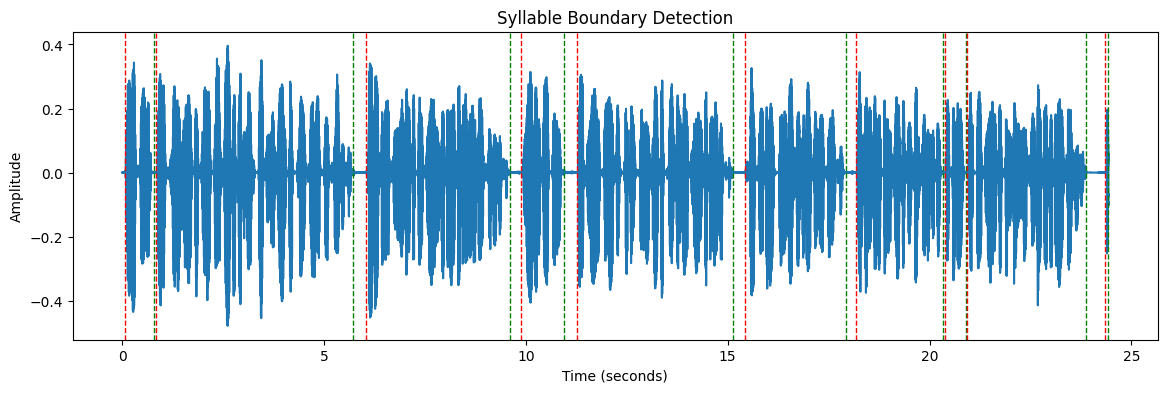

Waveform image saved: syllable_boundaries_waveform.png
Audio saved: syllable_detected_audio.wav

Detected syllables:

Syllable 1: 0.064 sec -> 0.800 sec
Syllable 2: 0.832 sec -> 5.728 sec
Syllable 3: 6.048 sec -> 9.600 sec
Syllable 4: 9.888 sec -> 10.944 sec
Syllable 5: 11.264 sec -> 15.136 sec
Syllable 6: 15.424 sec -> 17.920 sec
Syllable 7: 18.176 sec -> 20.320 sec
Syllable 8: 20.384 sec -> 20.896 sec
Syllable 9: 20.928 sec -> 23.872 sec
Syllable 10: 24.352 sec -> 24.430 sec


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import librosa
import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt

# -----------------------------
# Upload audio file
# -----------------------------
print("Choose your audio file (.wav or .pcm)")
uploaded = files.upload()

audio_path = list(uploaded.keys())[0]
print("Selected:", audio_path)

# -----------------------------
# Convert PCM → WAV if needed
# -----------------------------
if audio_path.endswith(".pcm"):
    sr = 16000
    data = np.fromfile(audio_path, dtype=np.int16)

    wav_path = audio_path.replace(".pcm", ".wav")
    sf.write(wav_path, data, sr)

    audio_path = wav_path
    print("PCM converted to WAV")

# -----------------------------
# Load audio
# -----------------------------
y, sr = librosa.load(audio_path, sr=None)
duration = len(y) / sr
print("Duration:", duration, "seconds")

# -----------------------------
# Detect syllable regions
# -----------------------------
intervals = librosa.effects.split(
    y,
    top_db=30,
    frame_length=2048,
    hop_length=512
)

# -----------------------------
# Convert to seconds
# -----------------------------
syllables = []

for start, end in intervals:
    start_sec = start / sr
    end_sec = end / sr
    syllables.append([start_sec, end_sec])

# -----------------------------
# Save Excel
# -----------------------------
df = pd.DataFrame(
    syllables,
    columns=["Syllable Start (sec)", "Syllable End (sec)"]
)

excel_file = "syllable_boundaries.xlsx"
df.to_excel(excel_file, index=False)

print("Excel saved:", excel_file)

# -----------------------------
# Plot waveform with boundaries
# -----------------------------
time = np.linspace(0, duration, len(y))

plt.figure(figsize=(14,4))
plt.plot(time, y)

for start, end in syllables:
    plt.axvline(start, linestyle="--", color="red", linewidth=1)
    plt.axvline(end, linestyle="--", color="green", linewidth=1)

plt.title("Syllable Boundary Detection")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

image_file = "syllable_boundaries_waveform.png"
plt.savefig(image_file)
plt.show()

print("Waveform image saved:", image_file)

# -----------------------------
# Save syllable-only audio
# -----------------------------
output_audio = np.zeros_like(y)

for start, end in intervals:
    output_audio[start:end] = y[start:end]

sf.write("syllable_detected_audio.wav", output_audio, sr)

print("Audio saved: syllable_detected_audio.wav")

# -----------------------------
# Print boundaries
# -----------------------------
print("\nDetected syllables:\n")

for i,(s,e) in enumerate(syllables):
    print(f"Syllable {i+1}: {s:.3f} sec -> {e:.3f} sec")

# -----------------------------
# Auto download Excel
# -----------------------------
files.download(excel_file)